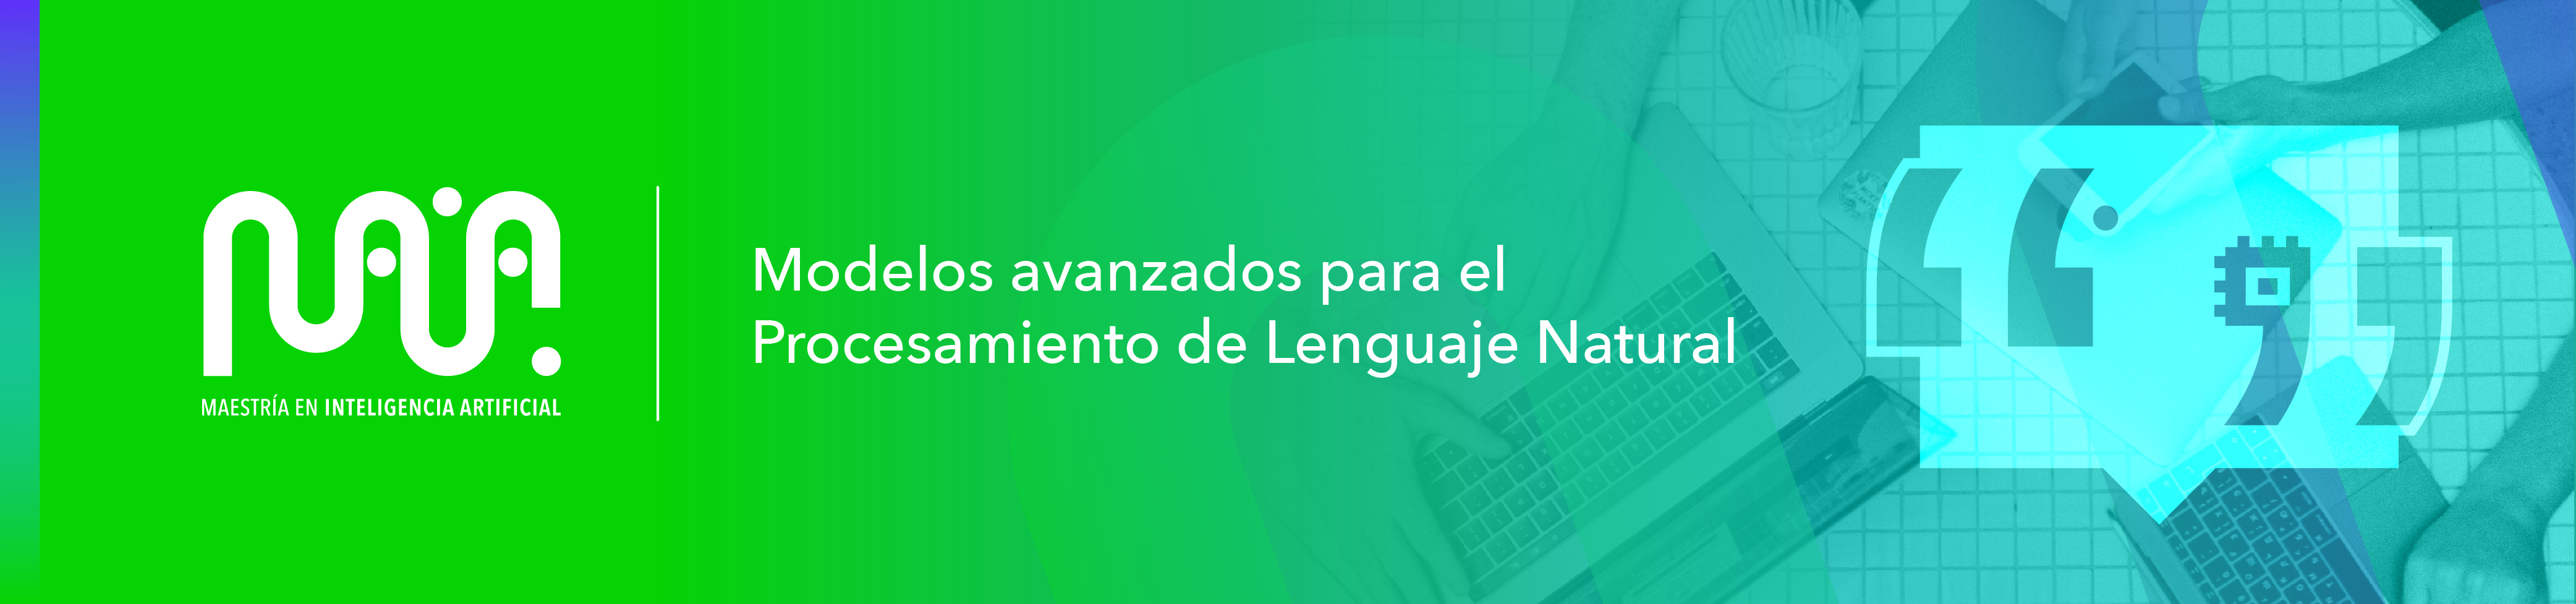
# Tutorial: Modelos de lenguaje con redes neuronales recurrentes (RNNs)

En este Jupyter Notebook se presenta una introducción a las redes neuronales recurrentes, viendo en detalle la implementación de una RNN simple, además de conocer arquitecturas más complejas como las RNN apiladas, y las LSTM. A lo largo del notebook se hace uso de un corpus de texto de Shakespeare para entrenar modelos de lenguaje y evaluar el desempeño de las distintas arquitecturas implementadas.

**Los objetivos de aprendizaje son:**

1. Entender los fundamentos detrás de las RNNs.
2. Implementar con Pytorch una RNN desde cero.
3. Hacer uso de arquitecturas de redes recurrentes avanzadas.
4. Usar las redes recurrentes para entrenar modelos de lenguaje.
5. Entrenar y evaluar los modelos de lenguaje.
6. Conocer técnicas para mejorar la generación de texto de los modelos de lenguaje.

## Metodología

El tutorial desarrolla de manera progresiva los conceptos necesarios para la construcción de modelos de lenguaje con redes neuronales recurrentes. La estructura de este notebook es la siguiente:

* 1. Preparando el dataset
* 2. Introducción a las redes neuronales recurrentes (RNNs)
* 3. Entrenamiento de una RNN
* 4. Implementando RNNs con Pytorch
    * 4.1. RNNs apiladas
* 5. LSTMs
* 6. Mejorando la generación de texto
    * 6.1. Temperatura
    * 6.2. Top p
* 7. Conclusiones

## 1. Preparando el dataset

In [1]:
# Importar librerías
import torch
import numpy as np
import re
import string
import math
import matplotlib.pyplot as plt

torch.manual_seed(65) # Semilla para reproducibilidad
np.random.seed(89)


In [ ]:
# Leer el archivo de texto
with open('input.txt') as file:
    corpus = file.read()

# Ver los primeros 1000 caracteres del corpus
print(corpus[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



Ahora vamos a tokenizar el corpus. En esta ocasión vamos a definir nuestras propias reglas de tokenización.

In [3]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [4]:
# reglas en para definir un token:
# 1. caracter de nueva linea es su propio token
# 2. Un espacio (opcional) seguido de una palabra es un token. Por ejemplo " hola" o "hola".
# 3. Una secuencia de digitos seguidos conforman un token
# 4. Cualquier caracter de espaciado que no se encuentre antes de una palabra
# 5. Contracciones comunes: 't, 've, 'll, 's, and 'd
# 6. Secuencia de caracteres de puntuación: !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~

patt = rf"\n|\s?\w+|\d+|\s|'t|'ve|'ll|'s|'d|[{string.punctuation}]+"

sample = "\n hola1232 123 we've...  hey"
re.findall(patt, sample)

['\n', ' hola1232', ' 123', ' we', "'ve", '...', ' ', ' hey']

In [5]:
# Tokenizamos el corpus
tokenized = re.findall(patt, corpus)
# Imprimimos los primeros 100 tokens
print(tokenized[:100])

['First', ' Citizen', ':', '\n', 'Before', ' we', ' proceed', ' any', ' further', ',', ' hear', ' me', ' speak', '.', '\n', '\n', 'All', ':', '\n', 'Speak', ',', ' speak', '.', '\n', '\n', 'First', ' Citizen', ':', '\n', 'You', ' are', ' all', ' resolved', ' rather', ' to', ' die', ' than', ' to', ' famish', '?', '\n', '\n', 'All', ':', '\n', 'Resolved', '.', ' resolved', '.', '\n', '\n', 'First', ' Citizen', ':', '\n', 'First', ',', ' you', ' know', ' Caius', ' Marcius', ' is', ' chief', ' enemy', ' to', ' the', ' people', '.', '\n', '\n', 'All', ':', '\n', 'We', ' know', "'t", ',', ' we', ' know', "'t", '.', '\n', '\n', 'First', ' Citizen', ':', '\n', 'Let', ' us', ' kill', ' him', ',', ' and', ' we', "'ll", ' have', ' corn', ' at', ' our', ' own']


Ahora creamos el vocabulario del corpus.

In [6]:
# Vocabulario de tokens únicos en el corpus
vocabulary = sorted(set(tokenized)) # Se ordena el vocabulario de manera que siempre generemos los mismos ids
print(f'El corpus tiene {len(vocabulary):,} tokens de vocabulario')

# Diccionario para codificar los tokens
stoi = {s:i for i,s in enumerate(vocabulary)}
# Diccionario para decodificar los tokens
itos = {i:s for i,s in enumerate(vocabulary)}

El corpus tiene 15,052 tokens de vocabulario


Codificamos el corpus para tener un arreglo de números, en donde cada número representa un token.

In [7]:
encoded_corpus = [stoi[tok] for tok in tokenized]
print(f'El corpus tiene {len(encoded_corpus):,} tokens en total')

El corpus tiene 298,452 tokens en total


Esta vez vamos a reservar el 10% de tokens finales del corpus como nuestros datos de validación con los que más adelante podremos evaluar la capacidad de generalización de los modelos que construyamos.

In [8]:
k = int(len(encoded_corpus)*0.9)
train_corpus = encoded_corpus[:k]
print(f'El set de entrenamiento tiene {len(train_corpus):,} tokens.')
val_corpus = encoded_corpus[k:]
print(f'El set de validación tiene {len(val_corpus):,} tokens.')

El set de entrenamiento tiene 268,606 tokens.
El set de validación tiene 29,846 tokens.


## 2. Introducción a las redes neuronales recurrentes (RNNs)

Las RNNs son modelos similares a las redes FeedForward o MLPs vistos en el tutorial de la semana 1. Sin embargo, se caracterizan por tener dependencias (recurrencias) con salidas del modelo en tiempos (valores de secuencia) anteriores.

Se presenta la siguiente figura para mayor claridad:

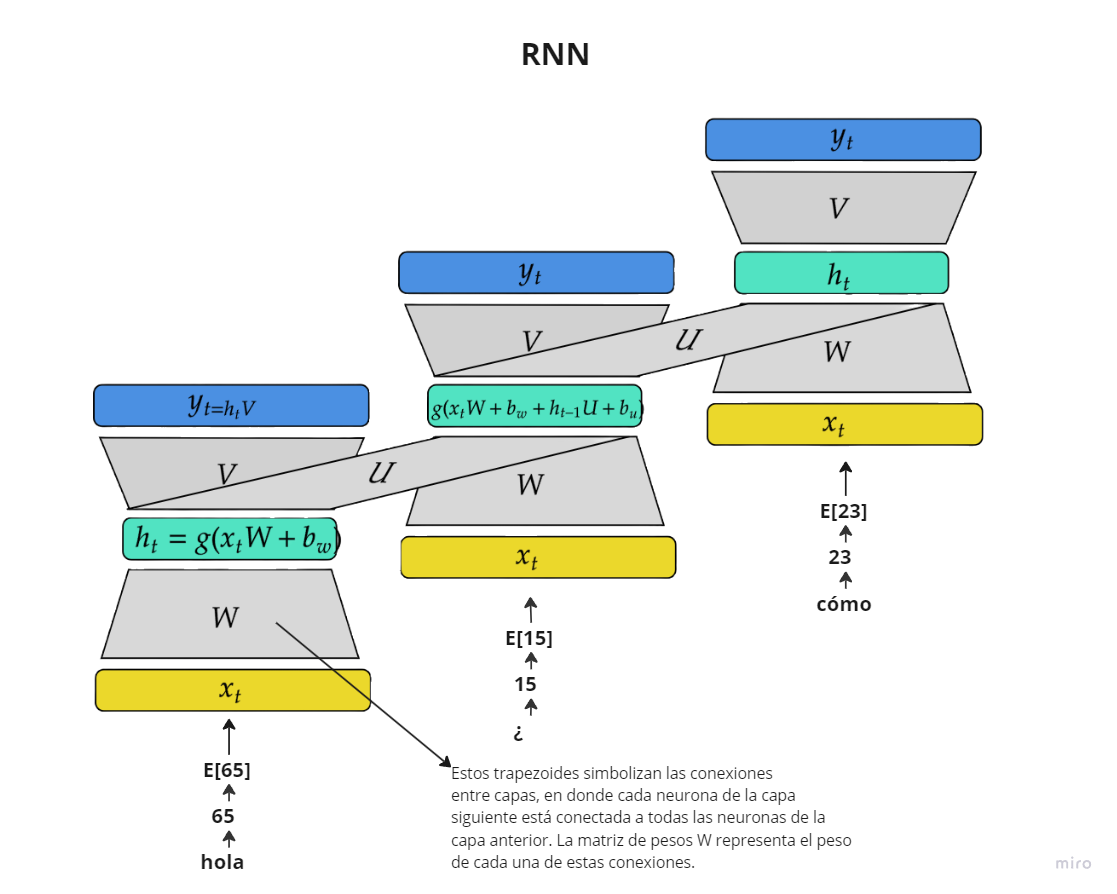

En la figura note como $h_3$, es decir, el estado oculto ($h_t$) de la tercera palabra depende a su vez del estado oculto de las dos palabras anteriores. En la figura (en el $h_t$ de la segunda palabra) también se detalla el cálculo del estado oculto, en donde se observa que el estado oculto depende de dos vectores de entrada, siendo el primero el embedding de la palabra "¿", y el segundo es el vector del estado oculto anterior ($h_{t-1}$). Sobre cada uno de estos vectores de entrada se realiza una transformación lineal (multiplicación de matrices más el bias) con las matrices de pesos $W$ y $U$ en el orden correspondiente, cuyos resultados se suman y se pasan por una función de activación no-lineal representada en este caso por $g()$.

Finalmente, es importante que observe como a pesar de que la matrices $W,U,V$ se utilizan en distintos tiempos $t$, estas matrices son las mismas para realizar todos los cálculos.

Antes de implementar la arquitectura de redes neuronales, vamos a crear la clase `DataLoader` con el fin de iterar sobre el corpus completo, y obtener lotes de ejemplos para realizar el entrenamiento del modelo. En la siguiente figura se detallan los datos de entrenamiento requeridos por un modelo recurrente con un contexto de 3 tokens. En este ejemplo, se muestra como cada uno de los ejemplos del lote debe consistir en 3 tokens ("hola", "¿", y "cómo" en la figura), los cuales se usarán como entrada al modelo, y como etiquetas se tendrá el token siguiente para cada uno de los tokens ("¿", "cómo", y "estás"), estas etiquetas se compararán con el resultado del modelo para realizar la optimización del mismo.

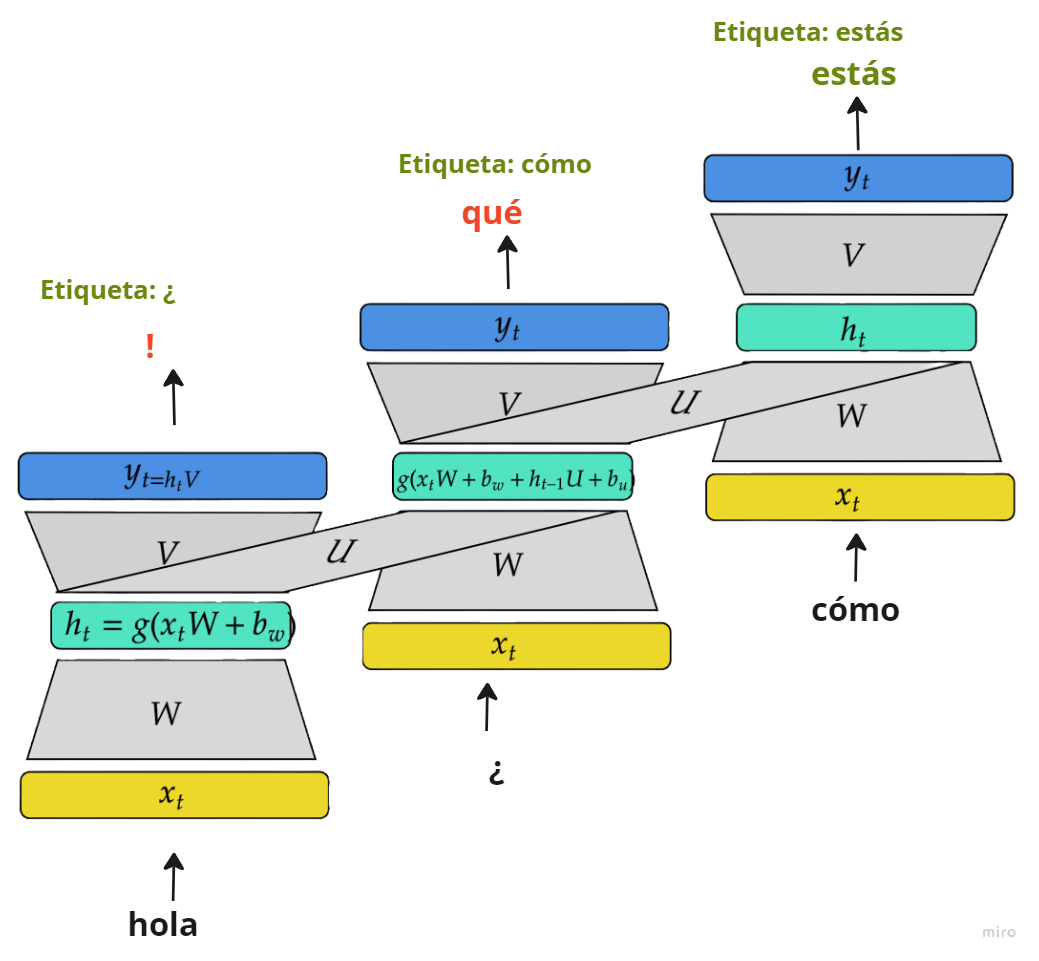

In [9]:
# Clase para iterar por lotes sobre el dataset
class DataLoader:
    def __init__(self, corpus, block_size) -> None:
        self.curr_pos = 0
        self.corpus = torch.tensor(corpus)
        # El corpus se itera completamente antes de iterar sobre él nuevamente
        # Sin embargo, cada vez que se recorre nuevamente se tomarán secuencias en un orden distinto para evitar el sobre ajuste del modelo
        self.examples_index = list(range(0, len(corpus)-block_size, block_size)) # Se asigna un índice a cada secuencia de tamaño block_size del corpus
        self.order = np.random.permutation(self.examples_index) # Se reordenan los índices para recorrer los ejemplos en un orden distinto
        self.block_size = block_size
        self.stride = 0 # Se agrega este argumento para que cuando se itere nuevamente sobre el corpus, el modelo no vea exactamente las mismas secuencias.
        # Por ejemplo si la primera vez vio ["hola", ",", "mucho"], en la segunda iteración vea [",", "mucho", "gusto"]

    # Método para obtener un lote de ejemplos
    def get_batch(self, batch_size):
        # índices del comienzo de las secuencias que se van a usar en el lote
        batch_examples = self.order[self.curr_pos:self.curr_pos+batch_size]
        # Puntero para recorrer el corpus completamente
        self.curr_pos += len(batch_examples)

        # Cuando se itere completamente sobre el corpus, se itera sobre él nuevamente en distinto orden
        if len(batch_examples) < batch_size:
            self.curr_pos = 0 # Se reinicia el puntero
            self.stride = (self.stride + 1) % self.block_size # Se aumenta el stride para no repetir exactamente las mismas secuencias
            # Se crean los índices de las secuencias que determinan la forma en la que se va a recorrer el corpus
            self.examples_index = list(range(self.stride, len(self.corpus)-self.block_size, self.block_size))
            self.order = np.random.permutation(self.examples_index)
            # En caso de que el lote final esté vació (no tenga ejemplos), tomar el lote nuevamente
            if  len(batch_examples) == 0:
                batch_examples = self.order[self.curr_pos:self.curr_pos+batch_size]
                self.curr_pos += len(batch_examples)

        # Por cada id que representa el índice del comienzo de una secuencia tomar los tokens de contexto correspondientes
        x = torch.stack([self.corpus[idx:idx+self.block_size] for idx in batch_examples], dim=0)
        # Como etiqueta se toma el token siguiente a cada uno de los tokens de la secuencia de entrada
        y = torch.stack([self.corpus[idx+1:idx+1+self.block_size] for idx in batch_examples], dim=0)
        return x, y

Ejemplo de los datos de entrenamiento:

In [10]:
# Vamos a tomar los primeros 10 tokens del dataset con un contexto de 3 palabras
block_size = 3
data = DataLoader(encoded_corpus[:10], block_size)

In [11]:
# Función para decodificar los tokens
decode = lambda x: [itos[s.item()] for s in x]

print('Corpus completo:')
print(decode(data.corpus))

# Vamos a recorrer el dataset con lotes de 2 ejemplos
batch_size = 2

# Vamos a iterar 3 veces sobre este mini corpus de 10 tokens
batches_per_corpus = math.ceil(((len(data.corpus) -1) // block_size) / batch_size) # Se descuenta del tamaño del corpus la etiqueta para que los ejemplos estén completos
print(f'En {batches_per_corpus} lotes se recorre el corpus de manera completa')

print('\n')
# Ver ejemplos de entrenamiento
for i in range(batches_per_corpus+1):
    print(f'Lote {i+1}')
    x, y = data.get_batch(batch_size)
    print('curr_pos', data.curr_pos)

    for example in range(x.shape[0]):
        print(f'Ejemplo {example+1} del lote')
        for context_length in range(x[example].shape[0]):
            context = decode(x[example][:context_length+1])
            target = decode([y[example][context_length]])
            print(f'context: {context} -> {target}')
        print('')
    print('--------------------------')

Corpus completo:
['First', ' Citizen', ':', '\n', 'Before', ' we', ' proceed', ' any', ' further', ',']
En 2 lotes se recorre el corpus de manera completa


Lote 1
curr_pos 2
Ejemplo 1 del lote
context: ['\n'] -> ['Before']
context: ['\n', 'Before'] -> [' we']
context: ['\n', 'Before', ' we'] -> [' proceed']

Ejemplo 2 del lote
context: ['First'] -> [' Citizen']
context: ['First', ' Citizen'] -> [':']
context: ['First', ' Citizen', ':'] -> ['\n']

--------------------------
Lote 2
curr_pos 0
Ejemplo 1 del lote
context: [' proceed'] -> [' any']
context: [' proceed', ' any'] -> [' further']
context: [' proceed', ' any', ' further'] -> [',']

--------------------------
Lote 3
curr_pos 2
Ejemplo 1 del lote
context: [' Citizen'] -> [':']
context: [' Citizen', ':'] -> ['\n']
context: [' Citizen', ':', '\n'] -> ['Before']

Ejemplo 2 del lote
context: ['Before'] -> [' we']
context: ['Before', ' we'] -> [' proceed']
context: ['Before', ' we', ' proceed'] -> [' any']

--------------------------


Observe como en los dos primeros lotes se recorre todo el dataset en un orden de secuencias arbitrario, mientras que en el tercer lote se inicia un nuevo recorrido sobre el dataset con secuencias organizadas de una manera que no fue vista en la primera iteración.

## 2. Implementación de una Red Neuronal Recurrente

En esta sección vamos a realizar una implementación desde 0 de una Red Neuronal Recurrente simple con 8 tokens de contexto.

In [12]:
# Vamos a entrenar un modelo con 8 tokens de contexto
block_size = 8
train_data = DataLoader(train_corpus, block_size)

Veamos un ejemplo de los datos de entrenamiento:

In [13]:
x, y = train_data.get_batch(32)

In [14]:
decode = lambda x: [itos[s.item()] for s in x]
print(x.shape, y.shape)

# Vamos a imprimir 4 ejemplos de secuencias de entrenamiento
for i in range(4):
    context = decode(x[i])
    target = decode([y[i][-1]])
    print(f'context: {context} -> {target}')

torch.Size([32, 8]) torch.Size([32, 8])
context: ['.', ' Let', ' us', ' withdraw', ' together', ',', '\n', 'And'] -> [' we']
context: [' here', ' do', ' stand', ' in', ' arms', ',', '\n', 'To'] -> [' prove']
context: [' thy', ' person', ' for', ' the', ' thrower', '-', 'out', '\n'] -> ['Of']
context: ['\n', 'I', "'ll", ' pawn', ' the', ' little', ' blood', ' which'] -> [' I']


In [15]:
# Nuestros datos de entrada son una matriz de 32 ejemplos (batch_size), y tokens de contexto
# Como etiquetas también tenemos 8 por cada ejemplo, ya que por cada tiempo tenemos una etiqueta
x.shape, y.shape

(torch.Size([32, 8]), torch.Size([32, 8]))

In [16]:
# Vamos a realizar el entrenamiento en GPU si está disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Ahora vamos a implementar la arquitectura de redes recurrentes presentada con un contexto de 8 de tokens. La cual podría representarse de la siguiente forma:

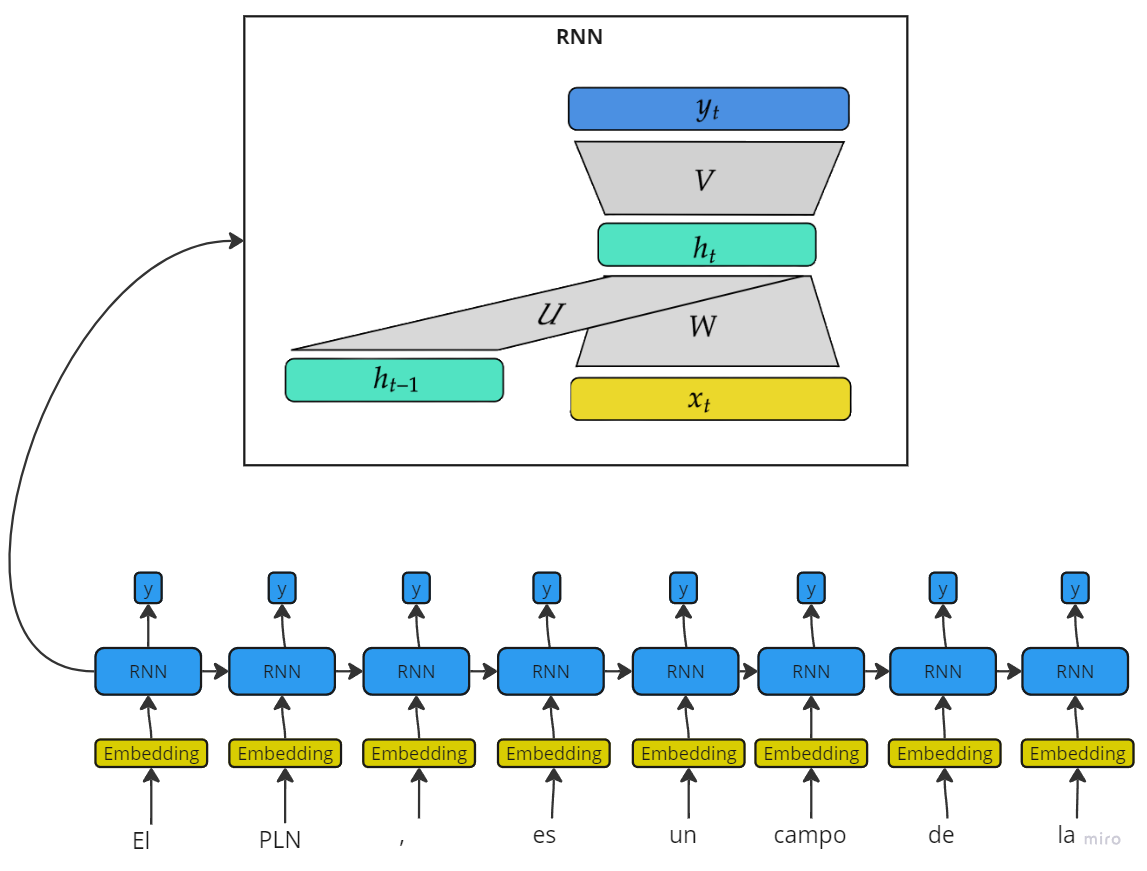

In [17]:
vocab_size = len(vocabulary)
embed_dim = 128 # Tamaño de la representación de cada token
batch_size = 512
hidden_layer = 2048 # Tamaño del vector h_t (estado oculto del token en el tiempo t)
context = block_size

# Definimos una clase que hereda de la clase torch.nn.Module para reusar las funcionalidades de las capas y modelos de Pytorch
class SimpleRNN(torch.nn.Module):
    # En el método de inicialización de la clase se deben definir los parámetros del modelo
    def __init__(self) -> None:
        # Inicializamos la clase padre
        super().__init__()
        # Usamos torch.nn.Parameter para registrar los tensores con los pesos
        # Pesos de la capa de embeddings
        self.E = torch.nn.Parameter(torch.randn((vocab_size, embed_dim)))
        # Pesos de W
        self.W = torch.nn.Parameter(torch.randn((embed_dim, hidden_layer)) * embed_dim**-0.5) # Se utiliza la inicialización de Kaiming para los pesos con los que se realiza producto punto
        self.wb = torch.nn.Parameter(torch.zeros((hidden_layer,)))
        # Pesos de U
        self.U = torch.nn.Parameter(torch.randn((hidden_layer, hidden_layer)) * hidden_layer**-0.5)
        self.ub = torch.nn.Parameter(torch.zeros((hidden_layer,)))
        # Pesos de V para la capa de salida de tamaño del vocabulario
        self.V = torch.nn.Parameter(torch.randn((hidden_layer, vocab_size)) * hidden_layer**-0.5)

    # En el método forward se definen las operaciones a realizar para transformar el input en la salida del modelo
    def forward(self, x): # x -> [batch_size, block_size]
        # Capa de embedding
        xt = self.E[x] # [batch_size, block_size, embed_dim]

        previous_h = None
        # Creamos un tensor vació para almecenar los estados ocultos por cada tiempo
        hts = torch.zeros(x.shape[0], x.shape[1], hidden_layer, device=device) # # [batch_size, block_size, hidden_layer]
        # La recurrencia la implementaremos mediante un bucle for
        for i in range(x.shape[1]): # Se itera sobre los tiempos de la secuencia (tokens en este caso)
            # Se realiza la primera transformación de la entrada con el tensor W
            ht = xt[:,i,:] @ self.W + self.wb # [batch_size, embed_dim] @ [embed_dim, hidden_layer] + [hidden_layer] = [batch_size, hidden_layer]
            # Note como con xt[:,i,:] se accede únicamente al embedding del token i.
            if previous_h is not None: # El primer token únicamente tiene en cuenta la transformación con W para calcular la salida
                # Traer la información relevante del estado oculto anterior
                from_memory = previous_h @ self.U + self.ub # [batch_size, hidden_layer] @ [hidden_layer, hidden_layer12] + [hidden_layer] = [batch_size, hidden_layer]
                # Se suma la información que se trajo del estado oculto anterior con la transformación del token de entrada
                ht = ht + from_memory # [batch_size, hidden_layer]
            # Se aplica la función de activación no-lineal
            ht = torch.nn.functional.relu(ht)
            # Se guarda el estado oculto del token i como el estado oculto anterior para ser utilizado por el siguiente token
            previous_h = ht
            # Se agrega al tensor de estados oculto el estado oculto final del token i
            hts[:,i] = ht
        # Para optimizar el rendimiento del modelo, la transfomación V para calcular las salidas se puede calcular sobre todos los estados ocultos al tiempo
        y_preds = hts @ self.V # [batch_size, block_size, hidden_dim] @ [hidden_dim, vocab_size] = [batch_size, block_size, vocab_size]
        # Por cada ejemplo y por cada tiempo t se generó un vector de salida del tamaño del vocabulario para predecir el siguiente token
        return y_preds # [batch_size, block_size, vocab_size]


## 3. Entrenamiento de una RNN

En esta sección se dará una muestra de cómo realizar el entrenamiento de una RNN.

In [18]:
# Se calcula a cuántos lotes de entrenamiento corresponde una iteración completa por el corpus
steps_per_epoch = int(len(train_data.corpus) / (batch_size * block_size))
steps_per_epoch

65

A diferencia de los modelos implementados en la semana 1. En esta ocasión, vamos a ser más rigurosos con la evaluación de los modelos implementados, para medir de mejor manera el desempeño de nuestro modelo a medida que realizamos el entrenamiento. Para lograrlo, queremos hacer dos cambios importantes:

1. En los modelos de la semana 1 por cada paso de entrenamiento solo imprimimos el valor de pérdida del lote. Sin embargo, este valor no es representativo del valor de pérdida que obtendríamos si evaluaramos el modelo en el set de entrenamiento completo. Por esa razón, periódicamente vamos a realizar una estimación del valor de pérdida sobre el set de entrenamiento completo con el fin de hacer seguimiento a la capacidad del modelo para predecir el token siguiente en este set.

2. En segunda instancia, queremos saber que tan bien nuestro modelo está generalizando, es decir, que tan bueno es nuestro modelo en la predicción del siguiente token para secuencias de texto que nunca vio en su entrenamiento. Razón por lo que implementaremos una estimación del valor de pérdida periódica sobre el set de validación.

In [19]:
# Set con los datos de entrenamiento
train_eval = DataLoader(train_corpus, block_size)
# Set con los datos de validación
val_eval = DataLoader(val_corpus, block_size)


# Función para estimnar el valor de pérdida en el set de entrenamiento, y en el de validación
@torch.no_grad
def estimate_loss(model: torch.nn.Module, train_eval: DataLoader, val_eval: DataLoader, batch_size: int = 256, eval_iters: int = 10):
    model.eval() # Se debe informar a Pytorch que estamos en modo evaluación, esta información puede ser usada por alguna de las capas usadas como por ejemplo Dropout
    train_losses = []
    val_losses = []
    # Iteramos sobre un número de lotes definido para tener una mejor estimación del valor de pérdida en cada uno de los sets
    for i in range(eval_iters):
        x, y = train_eval.get_batch(batch_size)
        x, y = x.to(device), y.to(device) # Se envían los tensores al dispositivo en el que tenemos el modelo, ya sea CPU o GPU
        y_pred = model(x) # Se calculan los logits
        loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1)) # Se calcula el valor de pérdida
        train_losses.append(loss.item())

        # Se realizan los mismos pasos en el set de validación
        x, y = val_eval.get_batch(batch_size)
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1))
        val_losses.append(loss.item())
    train_loss = sum(train_losses)/eval_iters
    val_loss = sum(val_losses)/eval_iters

    model.train()
    return train_loss, val_loss

rnn = SimpleRNN()

print(f'El modelo tiene {sum([p.nelement() for p in rnn.parameters()]):,} parámetros.')

El modelo tiene 37,213,696 parámetros.


En la siguiente celda se realiza el entrenamiento del modelo. En el entorno de ejecución de Google Colab con GPUs disponibles la celda tarda alrededor de 6 minutos en ejecutarse.

In [20]:
rnn.to(device) # Se envía el modelo al dispositivo correspondiente
learning_rate = 0.001 # Tasa de aprendizaje para realizar la optimización

# Se van a guardar las estimaciones de pérdida durante el entrenamiento en los siguientes arreglos
train_losses = []
val_losses = []

rnn.train() # Se informa a Pytorch que se tiene el modelo en modo entrenamiento
# Se inicializa un optimizador Adam. A este optimizador se deben pasar los parámetros del modelo
optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate, weight_decay=0.001) # Se agrega una constante en weight_decay para controlar el sobre ajuste del modelo (aplica la penalización L2 a los pesos)

max_steps = 20*steps_per_epoch
print(f'Entrenamiento por {max_steps} pasos')
for step in range(max_steps):
    x, y = train_data.get_batch(batch_size)
    x, y = x.to(device), y.to(device)
    y_pred = rnn(x)
    loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1))

    # Limpiar los gradientes
    optimizer.zero_grad()
    # Calcular los gradientes
    loss.backward()
    # Actualizar los parámetros
    optimizer.step()

    # Logs
    if (step+1) % 100 == 0 or step == 0 or step == max_steps-1:
        # Estimar la pérdida de cada set
        train_loss, valid_loss = estimate_loss(rnn, train_eval, val_eval)
        print(f'Step {step+1:4d} - Train loss: {train_loss:4.2f} - Valid loss: {valid_loss:4.2f}')
        train_losses.append(train_loss)
        val_losses.append(valid_loss)

Entrenamiento por 1300 pasos
Step    1 - Train loss: 14.79 - Valid loss: 14.46
Step  100 - Train loss: 4.87 - Valid loss: 5.10
Step  200 - Train loss: 4.64 - Valid loss: 5.01
Step  300 - Train loss: 4.62 - Valid loss: 4.95
Step  400 - Train loss: 4.61 - Valid loss: 5.00
Step  500 - Train loss: 4.59 - Valid loss: 4.95
Step  600 - Train loss: 4.57 - Valid loss: 4.97
Step  700 - Train loss: 4.63 - Valid loss: 4.96
Step  800 - Train loss: 4.65 - Valid loss: 4.98
Step  900 - Train loss: 4.64 - Valid loss: 4.97
Step 1000 - Train loss: 4.68 - Valid loss: 4.94
Step 1100 - Train loss: 4.63 - Valid loss: 4.97
Step 1200 - Train loss: 4.70 - Valid loss: 4.97
Step 1300 - Train loss: 4.71 - Valid loss: 5.01


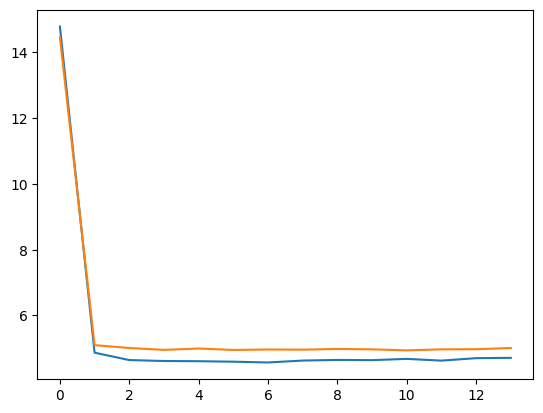

In [21]:
plt.plot(train_losses)
plt.plot(val_losses)

Definamos una función para realizar generación de texto:

In [22]:
@torch.no_grad
def generate(model, seed: torch.tensor, max_tokens = 200, max_context = block_size):
    model.eval() # Poner nuestro modelo en modo evaluación
    # Vamos a enviar nuestra semilla al mismo dispositivo que nuestro modelo
    generation = seed.clone().to(device)
    # Bucle de generación
    for i in range(max_tokens):
        pred = model(generation[:,-max_context:]) # Pásamos a nuestro modelo una entrada con máximo block_size tokens
        pred = pred[:,-1,:] # Solo tomamos la predicción realizada para el último token de la secuencia de entrada
        probs = torch.nn.functional.softmax(pred, dim=-1) # Convertimos la salida del modelo en una distribución de probabilidad
        next_tok = torch.multinomial(probs, 1) # Seleccionamos el siguiente token de forma aleatoria como una muestra de la distribución
        generation = torch.cat((generation, next_tok), dim=1) # Agregamos el nuevo token para realizar la siguiente generación
    return ''.join(decode(generation[0])) # Decodificamos los tokens

Veamos un ejemplo de generación con nuestro modelo:

In [23]:
seed = torch.tensor([[stoi['\n']]])
print(generate(rnn, seed))


Of more and drunken poor let them a noble,
Or along that head our bed of flight brood much,
Had the eastern blood ever no tooit that niece they have day.

PAULINA:
More hence from the country vow lines, long is yet at imagined,
Because cursed from the substance folks Stand.
How for someOurselves or I pray? it, bring, for bestrid of man!

First to:
 since am be not, not.

GLOUCESTER Mayor:
So, that trespass power;
My doctrine master any pander slippers rabbit.

Nurse:
Why, goodSeeking, is Duke, and pricks
 unfashionable fellow's worship in some pail begin strive forgive parliament lamb
DothSirs this heads again, breath both with a right, what,
Look, gentle a lord, isTear it.
Ay, go you do, sir, lament here the farmer
From, his rheums Wonder, your urge.

FLORIZELISABELLA and alike


Podemos observar cómo aunque el texto generado por el modelo no tiene mucho sentido, por lo menos tiene una estructura similar al corpus original.

## 4. Implementando RNNs con Pytorch

En esta sección en vez de partir de cero, vamos a utilizar capas de RNNs disponibles en la librería de Pytorch.

In [24]:
class TorchRNN(torch.nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        # La capa RNN de pytorch recibe como entrada los tokens previamente embebidos, por lo que debemos agregar la capa de embeddings previamente a la de RNN
        self.EmbedLayer = torch.nn.Embedding(vocab_size, embed_dim) # Pytorch dispone de la capa Embedding para implementar una capa de de embeddings fácilmente. Esta capa recibe como argumentos el número de elementos para los cuales se van a crear los embeddings, y las dimensiones que van a tener los embeddings
        self.rnn = torch.nn.RNN(embed_dim, hidden_layer, batch_first=True, nonlinearity='relu') # La capa de RNN de Pytorch recibe como argumentos las dimensiones de los embeddings,
        # y las dimensiones del estado oculto (h). Adicionalmente, se le debe indicar que en el formato de nuestros datos de entrada la primera dimensión representa el número de ejemplos del lote

        # La capa RNN de pytorch no realiza la transformación del estado oculto a la salida del modelo (V), por lo que debemos agregar esta capa de salida
        self.dense = torch.nn.Linear(hidden_layer, vocab_size, bias=False) # con Linear podemos definir capas densas en las que definimos el número de neuronas de entrada y de salida

    def forward(self, x):
        embeds = self.EmbedLayer(x)
        # La capa RNN de pytorch nos retorna una tupla en donde tenemos como primer elemento un arreglo con los estados ocultos por cada tiempo, y como segundo elemento
        # el estado oculto del último token
        output, ht = self.rnn(embeds)
        # Como necesitamos calcular una salida por cada token, necesitamos tener el estado oculto por cada token
        logits = self.dense(output)
        # Retornamos los logits por cada ejemplo y por cada token en la secuencia
        return logits

rnn = TorchRNN()

print(f'El modelo tiene {sum([p.nelement() for p in rnn.parameters()]):,} parámetros.')

El modelo tiene 37,213,696 parámetros.


Se evidencia que nuestra implementación de un modelo recurrente, y la implementación provista por Pytorch tienen exactamente el mismo número de parámetros.

Ahora realizamos el entrenamiento del modelo:

**Nota**: La siguiente ejecución tarda alrededor de 6 minutos ejecutándose en Google Colab con GPU activa.

In [25]:
rnn.to(device)

train_losses = []
val_losses = []


rnn.train()
optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate, weight_decay=0.001)

print(f'Entrenando por {max_steps} pasos')
for step in range(max_steps):
    x, y = train_data.get_batch(batch_size)
    x, y = x.to(device), y.to(device)
    y_pred = rnn(x)
    loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Logs
    if (step+1) % 100 == 0 or step == 0 or step == max_steps-1:
        train_loss, valid_loss = estimate_loss(rnn, train_eval, val_eval)
        print(f'Step {step+1:4d} - Train loss: {train_loss:4.2f} - Valid loss: {valid_loss:4.2f}')
        train_losses.append(train_loss)
        val_losses.append(valid_loss)

Entrenando por 1300 pasos
Step    1 - Train loss: 9.14 - Valid loss: 9.10
Step  100 - Train loss: 5.27 - Valid loss: 5.36
Step  200 - Train loss: 4.89 - Valid loss: 5.11
Step  300 - Train loss: 4.81 - Valid loss: 5.02
Step  400 - Train loss: 4.73 - Valid loss: 4.98
Step  500 - Train loss: 4.70 - Valid loss: 4.99
Step  600 - Train loss: 4.71 - Valid loss: 4.96
Step  700 - Train loss: 4.72 - Valid loss: 4.94
Step  800 - Train loss: 4.68 - Valid loss: 5.01
Step  900 - Train loss: 4.64 - Valid loss: 4.94
Step 1000 - Train loss: 4.68 - Valid loss: 4.94
Step 1100 - Train loss: 4.74 - Valid loss: 5.01
Step 1200 - Train loss: 4.74 - Valid loss: 4.97
Step 1300 - Train loss: 4.74 - Valid loss: 4.98


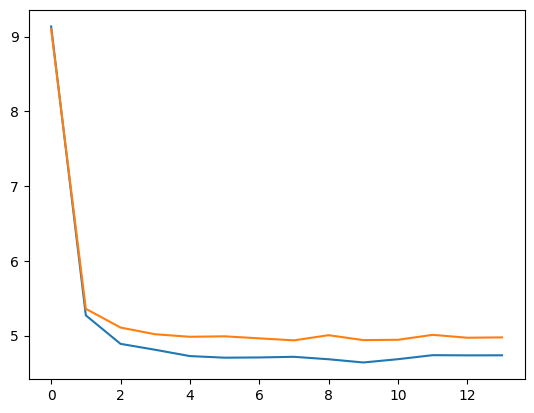

In [26]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.plot(val_losses)

### 4.1. RNNs apiladas

Las Redes neuronales recurrentes son modulares, de manera que pueden juntarse fácilmente con otro tipo de redes. De igual manera, se pueden apilar redes recurrentes una sobre otra, esto permite que la recurrencia pueda trabajar sobre diferentes niveles de abstracción. A continuación vamos a implementar la siguiente arquitectura con 3 capas recurrentes apiladas:

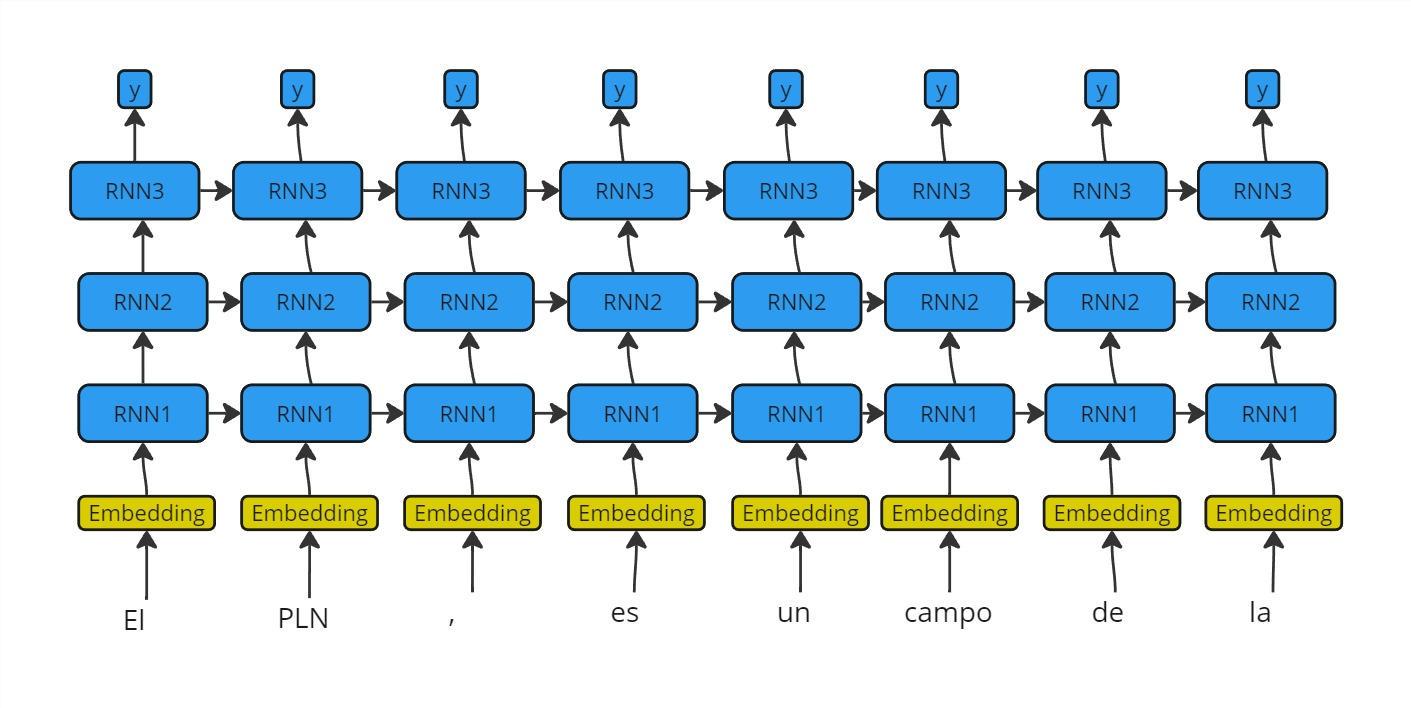

In [27]:
class StackedRNNs(torch.nn.Module):
    def __init__(self, stacked_layers_num, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.EmbedLayer = torch.nn.Embedding(vocab_size, embed_dim)
        self.stacked_rnn = torch.nn.RNN(embed_dim, hidden_layer, batch_first=True, dropout=0.5, nonlinearity='relu', num_layers=stacked_layers_num)
        self.dense = torch.nn.Linear(hidden_layer, vocab_size, bias=False)

    def forward(self, x):
        embeds = self.EmbedLayer(x)
        output, ht = self.stacked_rnn(embeds)
        logits = self.dense(output)
        return logits

model = StackedRNNs(3)
print(f'El modelo tiene {sum([p.nelement() for p in model.parameters()]):,} parámetros.')

El modelo tiene 53,999,104 parámetros.


En la siguiente celda se realiza el entrenamiento del modelo, esta ejecución tarda alrededor de 8 minutos ejecutándose en Google Colab con GPU activa.

In [28]:
model.to(device)
learning_rate = 0.001

train_losses = []
val_losses = []

# Training loop
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)

print(f'Training for {max_steps} steps')
for step in range(max_steps):
    x, y = train_data.get_batch(batch_size)
    x, y = x.to(device), y.to(device)
    y_pred = model(x)
    loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Logs
    if (step+1) % 100 == 0 or step == 0 or step == max_steps-1:
        train_loss, valid_loss = estimate_loss(model, train_eval, val_eval)
        print(f'Step {step+1:4d} - Train loss: {train_loss:4.2f} - Valid loss: {valid_loss:4.2f}')
        train_losses.append(train_loss)
        val_losses.append(valid_loss)

Training for 1300 steps
Step    1 - Train loss: 8.47 - Valid loss: 8.38
Step  100 - Train loss: 5.55 - Valid loss: 5.64
Step  200 - Train loss: 5.20 - Valid loss: 5.37
Step  300 - Train loss: 5.08 - Valid loss: 5.20
Step  400 - Train loss: 4.97 - Valid loss: 5.18
Step  500 - Train loss: 4.91 - Valid loss: 5.09
Step  600 - Train loss: 4.83 - Valid loss: 5.07
Step  700 - Train loss: 4.74 - Valid loss: 5.00
Step  800 - Train loss: 4.69 - Valid loss: 4.98
Step  900 - Train loss: 4.69 - Valid loss: 5.02
Step 1000 - Train loss: 4.66 - Valid loss: 5.00
Step 1100 - Train loss: 4.59 - Valid loss: 4.97
Step 1200 - Train loss: 4.63 - Valid loss: 4.97
Step 1300 - Train loss: 4.65 - Valid loss: 4.99


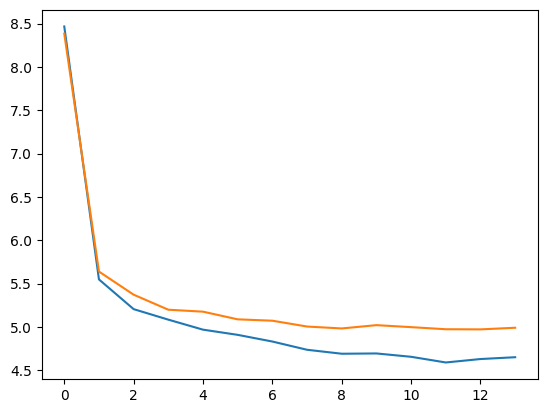

In [29]:
plt.plot(train_losses)
plt.plot(val_losses)

In [30]:
seed = torch.tensor([[stoi['\n']]])
print(generate(model, seed))


DUKE VINCENTIO:
I'll lay.

 mighty:
An, friar't starve:
For thee, not I think by their tortures
Was in mine dries
banishment'd my hope. What, to tell us here.

MARCIUS:
Lest you, thou he not know, that he came itself
Belike the payment:
O, heavily, 'tis awake.

BUCKINGHAM:
Thou often it will resisted from Paris.

MARCIUS:
That it mean do's life, therefore, though you live upon a love.

KING RICHARD II:
Amen, you think is no.
Come lies to speak?

QUEEN MARGARET:
Yet were more
 thorny thy honesty. Poor are 't, Duke;
And so, I do your sovereign,
Be our false towards his a soldier,
And answer his torch religion his death.

Gentleman:
The lord's mother you stay; and 'tis her truth?


## 5. LSTMs

Las RNN simples, en teoría, pueden manejar contextos de gran tamaño. Sin embargo, estudios empíricos han demostrado que su rendimiento es óptimo solo con contextos más reducidos. Esto se atribuye a que el estado oculto debe cumplir varias funciones simultáneamente, como determinar qué información recordar para la predicción del siguiente token, qué retener para futuras predicciones y qué olvidar.

En respuesta a esta limitación, se desarrolló la arquitectura Long Short-Term Memory (LSTM), que introduce mecanismos especializados para separar y gestionar estas tareas. Como resultado, las LSTM han mostrado un desempeño superior al de las RNN tradicionales y son capaces de trabajar eficazmente con contextos más largos.

In [31]:
block_size = 16
vocab_size = len(vocabulary)
embed_dim = 1024
batch_size = 512
hidden_layer = 1024

train_data = DataLoader(train_corpus, block_size)
train_eval = DataLoader(train_corpus, block_size)
val_eval = DataLoader(val_corpus, block_size)

In [32]:
class LSTM(torch.nn.Module):
    def __init__(self, stacked_layers_num, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.EmbedLayer = torch.nn.Embedding(vocab_size, embed_dim)
        self.lstm = torch.nn.LSTM(embed_dim, hidden_layer, batch_first=True, dropout=0.5, num_layers=stacked_layers_num)
        self.dense = torch.nn.Linear(hidden_layer, vocab_size, bias=False)

    def forward(self, x):
        embeds = self.EmbedLayer(x)
        output, ht = self.lstm(embeds)
        logits = self.dense(output)
        return logits

model = LSTM(3)
print(f'El modelo tiene {sum([p.nelement() for p in model.parameters()]):,} parámetros.')

El modelo tiene 56,016,896 parámetros.


In [33]:
# Función para definir el bucle de entrenamiento del modelo
def training_loop(model, lr, max_steps, data_loader: DataLoader, train_eval: DataLoader, val_eval: DataLoader, weight_decay: float = 0.0):
    train_losses = []
    val_losses = []

    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print(f'Entrenando por {max_steps} pasos')
    for step in range(max_steps):
        x, y = data_loader.get_batch(batch_size)
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Logs
        if (step+1) % 100 == 0 or step == 0 or step == max_steps-1:
            train_loss, valid_loss = estimate_loss(model, train_eval, val_eval)
            print(f'Step {step+1:4d} - Train loss: {train_loss:4.2f} - Valid loss: {valid_loss:4.2f}')
            train_losses.append(train_loss)
            val_losses.append(valid_loss)
    return train_losses, val_losses

In [34]:
steps_per_epoch = int(len(train_data.corpus) / (batch_size * block_size))
steps_per_epoch

32

En la siguiente celda se realiza el entrenamiento del modelo, esta ejecución tarda alrededor de 7 minutos ejecutándose en Google Colab con GPU activa.

In [35]:
model.to(device)
learning_rate = 0.002
train_losses, val_losses = training_loop(model, learning_rate, steps_per_epoch*20, train_data, train_eval, val_eval, weight_decay=0.0001)

Entrenando por 640 pasos
Step    1 - Train loss: 9.49 - Valid loss: 9.48
Step  100 - Train loss: 5.05 - Valid loss: 5.19
Step  200 - Train loss: 4.48 - Valid loss: 4.83
Step  300 - Train loss: 4.31 - Valid loss: 4.75
Step  400 - Train loss: 4.12 - Valid loss: 4.72
Step  500 - Train loss: 3.95 - Valid loss: 4.72
Step  600 - Train loss: 3.81 - Valid loss: 4.73
Step  640 - Train loss: 3.76 - Valid loss: 4.73


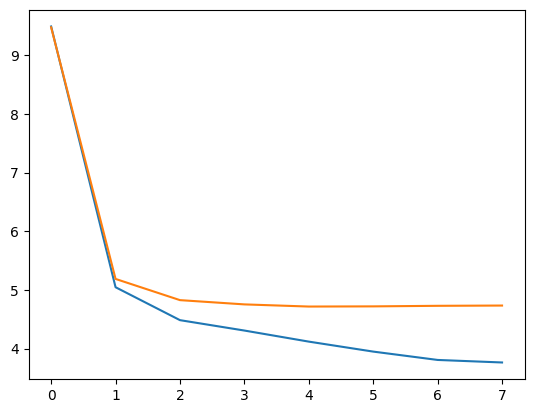

In [36]:
plt.plot(train_losses)
plt.plot(val_losses)

In [37]:
seed = torch.tensor([[stoi['\n']]])
print(generate(model, seed))


Tale justice, and thy own hand that will be a curse
A better wall than I should exile me,
And I will answer thee by your hurry courtesy.

ANGELO:
Nor became with thy noise.

LEONTES:
What guess is?

PETER:
How far doth't then I have waked:
And pratest, for this opinion of his justice
 seemed.

FRIAR LAURENCE:
Take his brother? the watch's court battle
This day should play from Rome wrongs from his word:
And only may well lose 't,
Were from afriend, that makes the utmost power
Intend before, or such as you seem.

WARWICK:
The army I say, fair enough and lay,
Be misapplied to me, my sovereign's loving air,
Which being as less of deep wreaths,
She seems we as his stone prints, pale him
From down and talk from justice. It will
Where we woo'd for


## 6. Mejorando la generación de texto

### 6.1. Temperatura

Para generar texto, utilizamos una distribución multinomial que selecciona el siguiente token de manera aleatoria, basada en las probabilidades asignadas por nuestro modelo a cada posible token. Esto puede generar problemas, ya que incluso tokens con probabilidades relativamente bajas podrían ser seleccionados durante la generación, lo que podría resultar en una secuencia que no tenga mucho sentido.

Una solución simple a este problema es escalar los logits asignados por el modelo, de modo que, al aplicar softmax, se amplifiquen las diferencias entre los tokens con mayor probabilidad y aquellos con menor probabilidad. Esto reduce la probabilidad de seleccionar tokens menos coherentes.

In [38]:
@torch.no_grad
def generate(model, seed: torch.tensor, max_tokens = 200, max_context = block_size, temperature = 1):
    model.eval() # Poner nuestro modelo en modo evaluación
    # Vamos a enviar nuestra semilla al mismo dispositivo que nuestro modelo
    generation = seed.clone().to(device)
    # Bucle de generación
    for i in range(max_tokens):
        pred = model(generation[:,-max_context:]) # Pásamos a nuestro modelo una entrada con máximo block_size tokens
        pred = pred[:,-1,:] # Solo tomamos la predicción realizada para el último token de la secuencia de entrada
        scaled_pred = pred / temperature # Se escalan los logits por el valor de temperatura. Note que si temperature=1 los logits permanecen igual
        probs = torch.nn.functional.softmax(scaled_pred, dim=-1) # Convertimos la salida del modelo en una distribución de probabilidad
        next_tok = torch.multinomial(probs, 1) # Seleccionamos el siguiente token de forma aleatoria
        generation = torch.cat((generation, next_tok), dim=1) # Agregamos el nuevo token para realizar la siguiente generación
    return ''.join(decode(generation[0])) # Decodificamos los tokens

In [39]:
seed = torch.tensor([[stoi['\n']]])
print(generate(model, seed, temperature=0.5))



DUKE VINCENTIO:
A very bawd, sir, I can tell
The gracious duke, and I'll not give you
To give him: and I'll give the crown with him.

GLOUCESTER:
I am a woman, and at the name of
the city, and were the very very
like of the
great a man, and not the thing of your own
in, and his own son.

MARCIUS:
I am a soldier, sir, and for the
 trick, sir, and the very trick of the duke.

MENENIUS:
I am sorry you will;
I am sure to-morrow, and I will love it.

DUKE VINCENTIO:
Sir, I am not to say for a thing as I
shall have a poison, as I am not
good.

CAMILLO:
I will not speak to you:
It is a man that's not a man,
And those in the field


### 6.2. Top p

Otra técnica que puede ayudarnos a mejorar la generación de texto de los modelos es **top p**, esta técnica consiste en solo tomar en cuenta los tokens para los cuales la probabilidad acumulada llega al valor definido. Si por ejemplo nuestro *top_p* es 0.8, el modelo al momento de generación va a considerar los tokens organizados por probabilidad de mayor a menor hasta aquel token para el cual se alcanza un 80% de probabilidad acumulada. De esta forma, se evita que por chance el modelo pueda llegar a generar tokens que no hacen sentido, y puedan además descarrilar la generación del modelo desde ese punto en adelante.

In [40]:
@torch.no_grad
def generate(model, seed: torch.tensor, max_tokens = 200, max_context = block_size, temperature = 1, top_p = 1):
    model.eval() # Poner nuestro modelo en modo evaluación
    # Vamos a enviar nuestra semilla al mismo dispositivo que nuestro modelo
    generation = seed.clone().to(device)
    # Bucle de generación
    for i in range(max_tokens):
        pred = model(generation[:,-max_context:]) # Pásamos a nuestro modelo una entrada con máximo block_size tokens
        pred = pred[:,-1,:] # Solo tomamos la predicción realizada para el último token de la secuencia de entrada
        scaled_pred = pred / temperature # Se escalan los logits por el valor de temperatura. Note que si temperature=1 los logits permanecen igual
        probs = torch.nn.functional.softmax(scaled_pred, dim=-1) # Convertimos la salida del modelo en una distribución de probabilidad

        # Ordenar las probabilidades en orden descendiente
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
        # Calcular la probabilidad acumulada
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        # Determinar el punto hasta el cual se van a considerar tokens
        cutoff = cumulative_probs <= top_p
        # Normalizar las probailidades tomando en cuenta solo los tokens que entran en el top_p
        top_p_probs = sorted_probs[cutoff]
        top_p_probs = top_p_probs/ top_p_probs.sum()

        # Si no hay tokens con probabilidad menor a top_p, utilizar la generación estándar
        if len(top_p_probs) == 0:
            probs = torch.nn.functional.softmax(scaled_pred, dim=-1)
            next_tok = torch.multinomial(probs, 1)
        else:
            next_tok = torch.multinomial(top_p_probs, 1) # Seleccionamos el siguiente token de forma aleatoria
            next_tok = (sorted_indices[0][next_tok]).unsqueeze(0)

        generation = torch.cat((generation, next_tok), dim=1) # Agregamos el nuevo token para realizar la siguiente generación
    return ''.join(decode(generation[0])) # Decodificamos los tokens

In [41]:
seed = torch.tensor([[stoi['\n']]])
print(generate(model, seed, temperature=0.8, top_p=0.6))


And make a life to the king, and my heart,
And with a one to my father's life
I am a subject, and to be a stubborn
That's the matter. The
I have a child, and say you, sir,
To save the holy blood, and in the earth
Of that same small grief of his
Lies, my lords, and my true hand shall
Will make her back to the ground, and let them be
In a child, and to make him to the king,
And all with that sorrow's past time
That did not kill his life, and in his love
That it is in my counsel,
To be a kind of honour, that I would
To see the law, and to his heart
To hear me hear the king, and will be
With all this earth, and I am sure to die.

QUEEN ELIZABETH:
Well, sir, you are too true; and I'll


## 7. Conclusiones

Las redes recurrentes, especialmente las LSTM, fueron muy populares para abordar una amplia variedad de tareas en el procesamiento de lenguaje natural (NLP). Sin embargo, en la actualidad, estas arquitecturas han sido reemplazadas por los Transformers, que ofrecen ventajas significativas como una mayor eficiencia en el entrenamiento y un desempeño superior en contextos de gran tamaño.

In [42]:
seed = torch.tensor([[stoi['thee']]])
print(generate(model, seed, temperature=1e-10, top_p=0))

thee,
And I am not a man to be a
good man, and that is not a man of the
great of the duke, and the poor duke, the
great the duke, the gods, and the gods,
The common and the sun, and the rest
Of the whole presence, and the rest of the
great the people, and the whole trick
of the whole ear, and the poor gentleman,
And, as I am, as I am sure, I am
a thing, sir, and to be a very man, as I am
not to be a little, if you have a
good, sir, and I am not a gentleman of the
great of the people, and the poor duke,
The common and the sun, and the gods
Of the whole presence, and the rest of the
great the people, and the whole trick
of the whole ear, and the poor gentleman,
And, as I am
